In [1]:
import sys
sys.path.insert(1, '/Users/linusrandud/Documents/UoM/ERP/MscDissertation/Deep-Opt')

In [2]:
# %env PYTORCH_ENABLE_MPS_FALLBACK=1

In [3]:
import torch
import wandb
import json
import numpy as np
import matplotlib.pyplot as plt
import random
import uuid

/Users/linusrandud/anaconda3/envs/myenv_3.9/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from COProblems.MKP import MKP
from COProblems.QUBO import QUBO
from Models.DOAE import DOAE
from OptimAE import OptimAEHandler

In [5]:
def check_constraints(solution, jobs):
    machine_jobs = [[], []]
    makespans = [0, 0]
    infeasible_count = 0
    
    for job_index, job_assignment in enumerate(solution):
        machine = int(job_assignment)
        job_key = job_index + 1
        job = jobs[job_key]
        machine_jobs[machine].append((job_key, job))
    
    for machine, assigned_jobs in enumerate(machine_jobs):
        current_time = 0
        for job_key, job in sorted(assigned_jobs, key=lambda x: (x[1]['deadline'], x[1]['release'])):
            if current_time < job['release']:
                current_time = job['release']
            current_time += job['duration']
            if current_time > job['deadline']:
                infeasible_count += 1
        makespans[machine] = current_time
    
    if infeasible_count > 0:
        return False, infeasible_count, makespans
    return True, infeasible_count, makespans

def find_extreme_indices(fitnesses, mode='high'):
    if mode not in ['high', 'low']:
        raise ValueError("Mode should be either 'high' or 'low'")

    if mode == 'high':
        extreme_value = max(fitnesses)
    else:
        extreme_value = min(fitnesses)

    return [i for i, value in enumerate(fitnesses) if value == extreme_value]

def convert_tensor_to_unique_np_arrays(tensor):
    np_array = tensor.numpy()
    np_array[np_array == -1] = 0
    unique_arrays = set()
    unique_np_arrays = []
    
    for arr in np_array:
        arr_tuple = tuple(arr)
        if arr_tuple not in unique_arrays:
            unique_arrays.add(arr_tuple)
            unique_np_arrays.append(arr)
    
    unique_np_array = np.array(unique_np_arrays)
    return unique_np_array

def get_solutions(population, fitnesses, mode='low'):
    return convert_tensor_to_unique_np_arrays(population[find_extreme_indices(fitnesses, mode)])

def load_jobs_from_json(file_path):
    with open(file_path, 'r') as f:
        jobs = json.load(f)
    
    # Convert keys to integers
    jobs = {int(k): v for k, v in jobs.items()}
    
    return jobs

In [6]:
# New parameter sets
# datasets = ['ssjsp_4', 'ssjsp_8', 'ssjsp_16', 'ssjsp_20']
datasets = ['ssjsp_200_s60']
constraint_methods = [None, 'binary', 'lagrangian']
pop_size_options = [1000]

# Parameters
base_params = {
    'change_tolerance': 50,
    'problem_size': None,  # Will be set for each dataset
    'pop_size': None,
    'dropout_prob': 0.2,
    'l1_coef': 0.0001,
    'l2_coef': 0.0001,
    'learning_rate': 0.002,
    'max_depth': 6,
    'compression_ratio': 0.8,
    'problem_instance_id': 0,
    'deepest_only': False,
    'encode': True,
    'repair_solutions': True,
    'patience': 5,  # Number of iterations to wait
    'delta_mean_population': 0.1,  # Threshold for mean population change
    'check_constraints': None,
    'penalty_mult': 5
}

# Number of iterations for stability
num_iterations = 3
device = torch.device("cpu")
problem_type = 'QUBO'
use_wandb = True

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.



Starting experiments for dataset ssjsp_200_s60 with population size 1000 and constraint method None
Iteration 1/3 for ssjsp_200_s60, constraint method: None, population size: 1000


wandb: Currently logged in as: linusrd. Use `wandb login --relogin` to force relogin


Instance has been loaded
Min pop fitness: -177528992.0, Mean pop fitness : -177528912.0
Min pop fitness: -177528992.0, Mean pop fitness : -177528960.0
Iteration 1, Depth 1, Evaluations: 59438, Mean Fitness: -177528960.0000, Min Fitness: -177528992.0000
Min pop fitness: -177528992.0, Mean pop fitness : -177528992.0
Iteration 1, Depth 2, Evaluations: 169331, Mean Fitness: -177528992.0000, Min Fitness: -177528992.0000
Min pop fitness: -177529008.0, Mean pop fitness : -177529008.0
Iteration 1, Depth 3, Evaluations: 327329, Mean Fitness: -177529008.0000, Min Fitness: -177529008.0000
Min pop fitness: -177529008.0, Mean pop fitness : -177529008.0
Iteration 1, Depth 4, Evaluations: 535405, Mean Fitness: -177529008.0000, Min Fitness: -177529008.0000
Min pop fitness: -177529008.0, Mean pop fitness : -177529008.0
Iteration 1, Depth 5, Evaluations: 793327, Mean Fitness: -177529008.0000, Min Fitness: -177529008.0000
Min pop fitness: -177529008.0, Mean pop fitness : -177529008.0
Iteration 1, Depth 6

current_iteration,▁▁▁▁▁▁▁▁
depth,▁▂▄▅▇███
mean_fitness,█▃▁▁▁▁▁▁
min_max_fitness,██▁▁▁▁▁▁
population_size,▁▁▁▁▁▁▁▁
total_eval,▁▁▂▃▄▅▇█
total_feasible_solutions_count,▁
total_infeasible_solutions,▁
current_iteration,1
dataset,ssjsp_200_s60
depth,6


...

Instance has been loaded
Min pop fitness: -177528080.0, Mean pop fitness : -177523216.0
Min pop fitness: -177528080.0, Mean pop fitness : -177525648.0
Iteration 2, Depth 1, Evaluations: 84590, Mean Fitness: -177525648.0000, Min Fitness: -177528080.0000
Min pop fitness: -177528128.0, Mean pop fitness : -177526464.0
Iteration 2, Depth 2, Evaluations: 217647, Mean Fitness: -177526464.0000, Min Fitness: -177528128.0000
Min pop fitness: -177528208.0, Mean pop fitness : -177526896.0
Iteration 2, Depth 3, Evaluations: 401445, Mean Fitness: -177526896.0000, Min Fitness: -177528208.0000
Min pop fitness: -177528320.0, Mean pop fitness : -177527200.0
Iteration 2, Depth 4, Evaluations: 630304, Mean Fitness: -177527200.0000, Min Fitness: -177528320.0000
Min pop fitness: -177528320.0, Mean pop fitness : -177527360.0
Iteration 2, Depth 5, Evaluations: 905500, Mean Fitness: -177527360.0000, Min Fitness: -177528320.0000
Min pop fitness: -177528352.0, Mean pop fitness : -177527440.0
Iteration 2, Depth 6

current_iteration,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
depth,▁▂▄▅▇███████████████████████████████████
mean_fitness,█▆▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
min_max_fitness,██▇▆▆▆▄▃▃▃▃▃▃▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
population_size,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_eval,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
total_feasible_solutions_count,▁
total_infeasible_solutions,▁
constraint_method,lagrangian
current_iteration,2
dataset,ssjsp_200_s60


Iteration 3/3 for ssjsp_200_s60, constraint method: lagrangian, population size: 1000


Instance has been loaded
Min pop fitness: -177527728.0, Mean pop fitness : -177523344.0
Min pop fitness: -177528256.0, Mean pop fitness : -177525632.0
Iteration 3, Depth 1, Evaluations: 85730, Mean Fitness: -177525632.0000, Min Fitness: -177528256.0000
Min pop fitness: -177528320.0, Mean pop fitness : -177526512.0
Iteration 3, Depth 2, Evaluations: 221050, Mean Fitness: -177526512.0000, Min Fitness: -177528320.0000
Min pop fitness: -177528320.0, Mean pop fitness : -177526912.0
Iteration 3, Depth 3, Evaluations: 403140, Mean Fitness: -177526912.0000, Min Fitness: -177528320.0000
Min pop fitness: -177528448.0, Mean pop fitness : -177527136.0
Iteration 3, Depth 4, Evaluations: 629991, Mean Fitness: -177527136.0000, Min Fitness: -177528448.0000
Min pop fitness: -177528560.0, Mean pop fitness : -177527328.0
Iteration 3, Depth 5, Evaluations: 905509, Mean Fitness: -177527328.0000, Min Fitness: -177528560.0000
Min pop fitness: -177528752.0, Mean pop fitness : -177527408.0
Iteration 3, Depth 6

current_iteration,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
depth,▁▂▄▅▇███████████████████████████████████
mean_fitness,█▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
min_max_fitness,█▇▇▆▅▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
population_size,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_eval,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
total_feasible_solutions_count,▁
total_infeasible_solutions,▁
constraint_method,lagrangian
current_iteration,3
dataset,ssjsp_200_s60


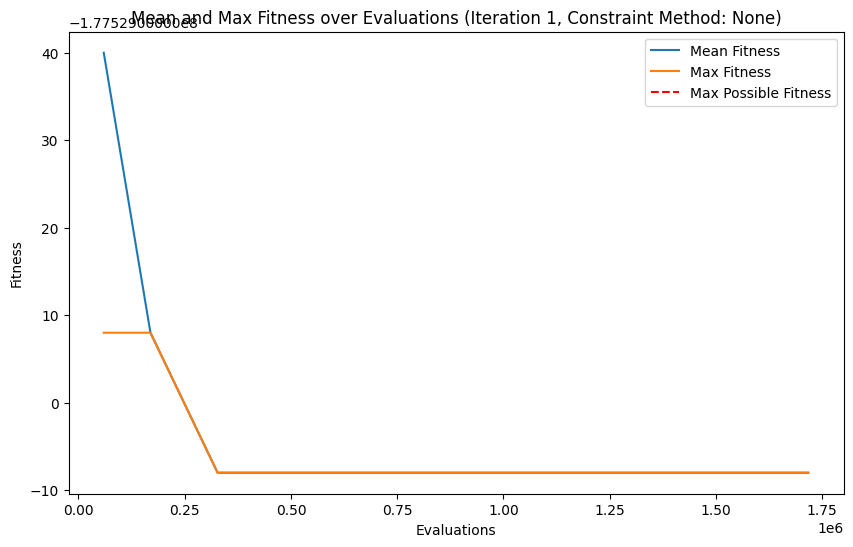

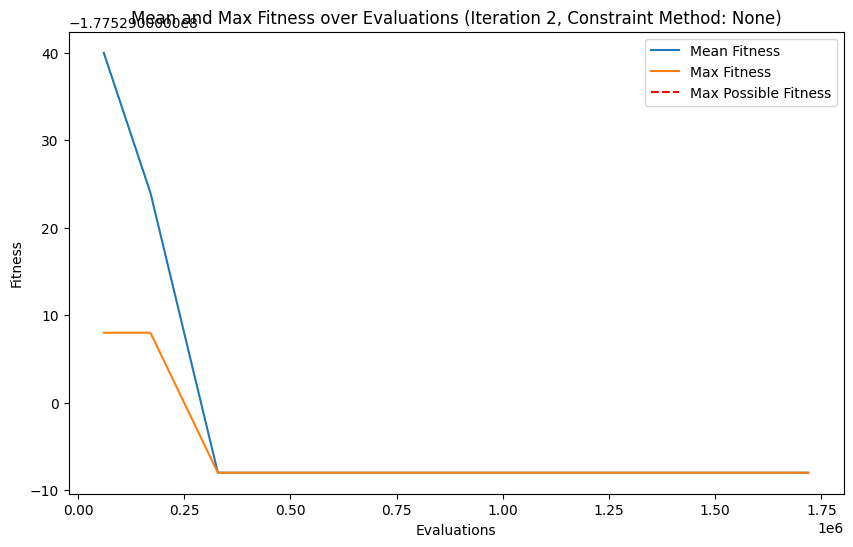

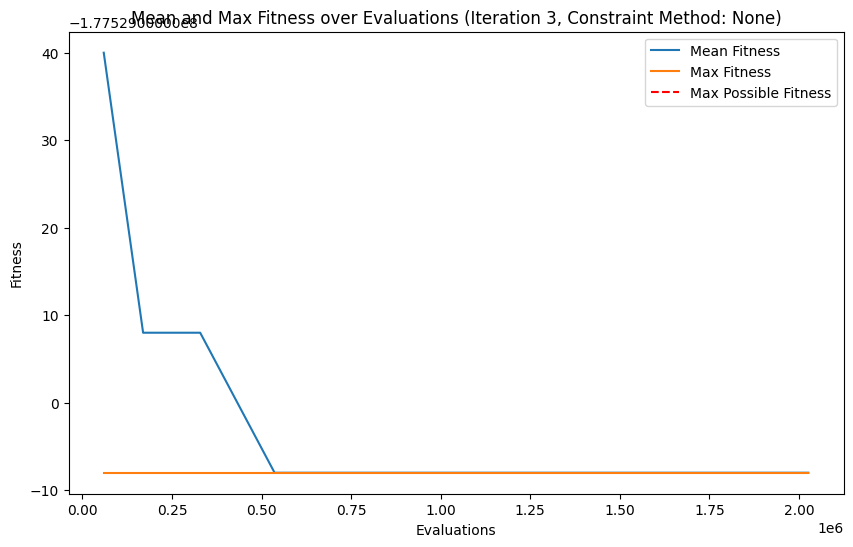

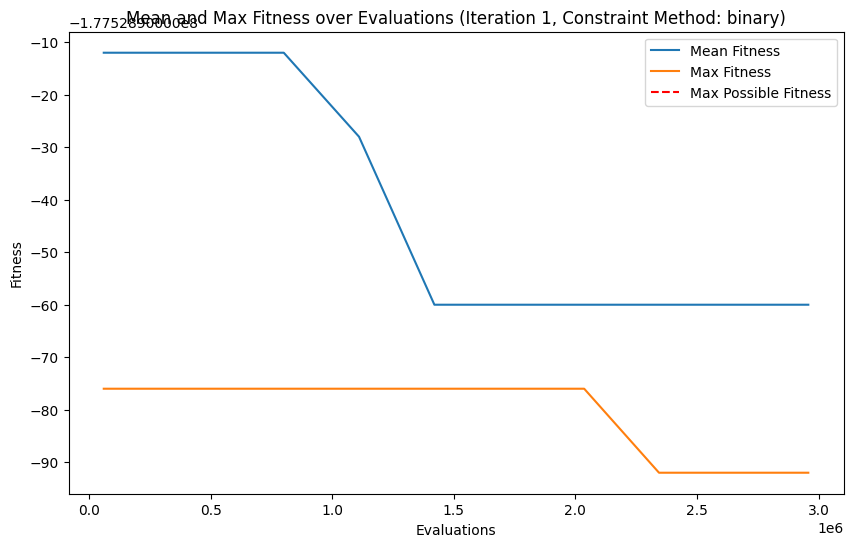

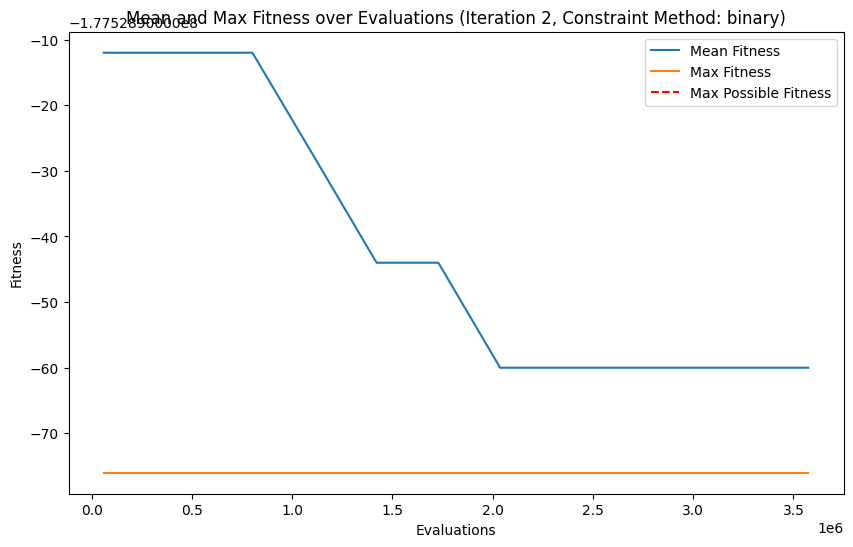

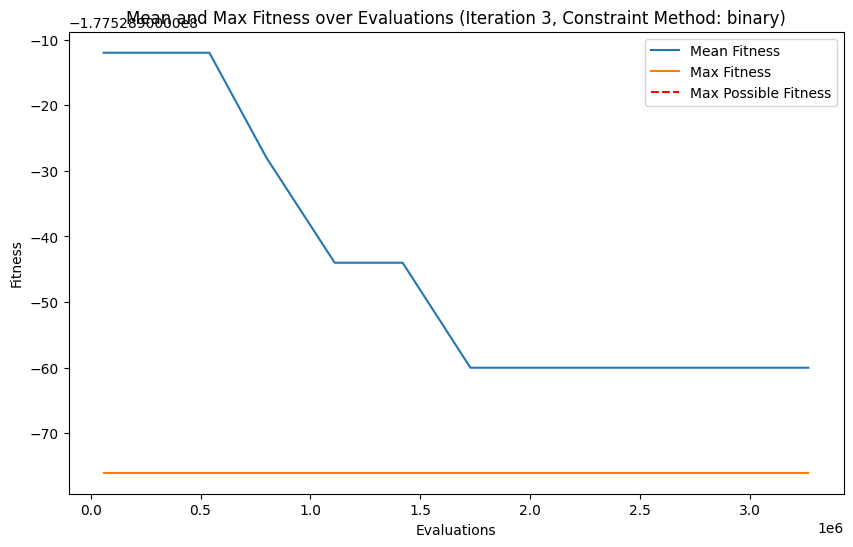

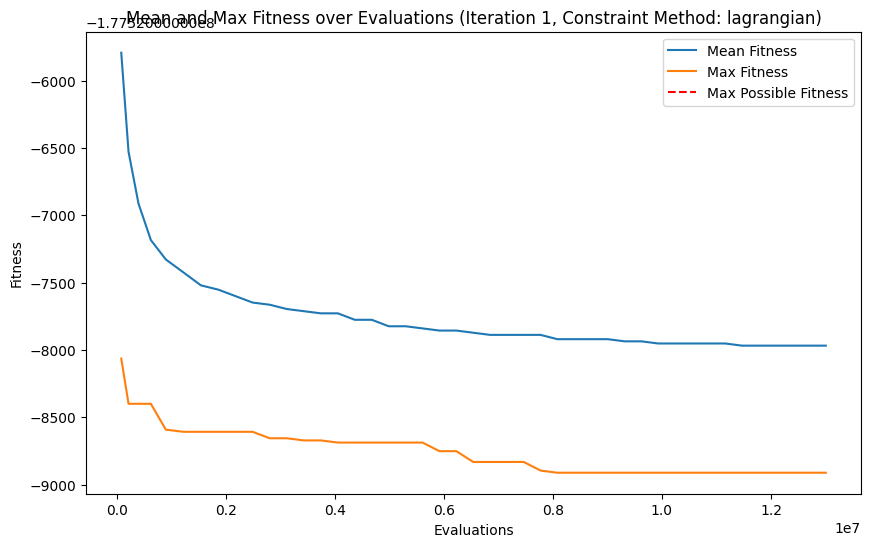

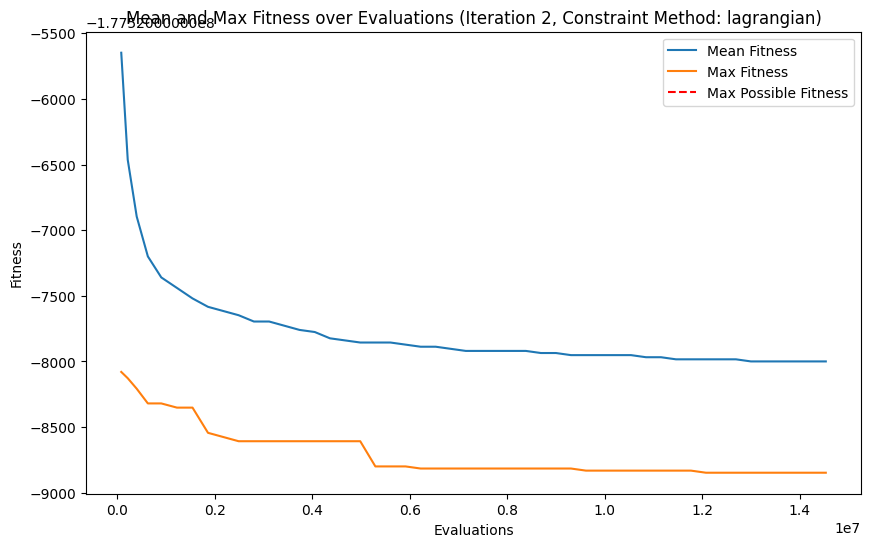

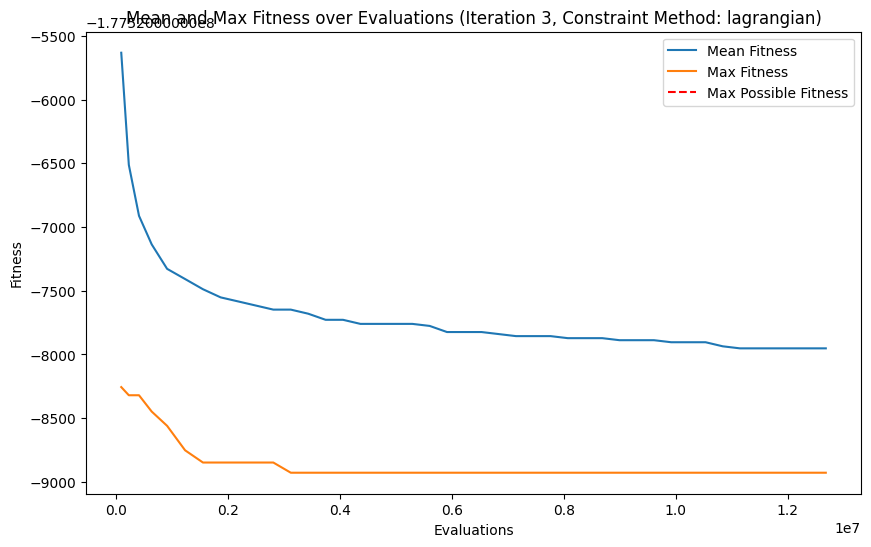

In [7]:
for dataset in datasets:
    for constraint_method in constraint_methods:  # Updated variable name
        for pop_size in pop_size_options:
            # Load jobs
            json_file = f'../data_gecco/ssjsp/{dataset}.json'
            jobs = load_jobs_from_json(json_file)

            # Set problem size based on the dataset
            file_paths = [f'../data_gecco/qubo/{dataset}.txt']
            problem_size = len(jobs)
            base_params['problem_size'] = problem_size
            base_params['pop_size'] = pop_size
            base_params['constraint_method'] = constraint_method

            print(f"\nStarting experiments for dataset {dataset} with population size {pop_size} and constraint method {constraint_method}")

            # Define a group name for the experiment
            group_name = f"{dataset}_popsize_{pop_size}_constraint_{constraint_method}"

            for iteration in range(num_iterations): # CHANGE THIS LATER!!!!!!!!
                unique_id = uuid.uuid4().hex  # Generate a unique ID for the pair

                print(f"Iteration {iteration + 1}/{num_iterations} for {dataset}, constraint method: {constraint_method}, population size: {pop_size}")

                if use_wandb:
                    wandb.init(
                        project="GECCO DO with Constraints ",
                        group=group_name,  # Grouping experiments
                        tags=[problem_type, f"constraint_method={constraint_method}", f"id={unique_id}"],
                        name=f"{dataset}_run_{iteration + 1}_{constraint_method}"
                    )
                    wandb.config.update(base_params)
                    wandb.log_artifact(json_file, type='dataset')

                if problem_type == 'QUBO':
                    problem = QUBO(file_paths[0], base_params['problem_instance_id'], device)
                    if base_params['constraint_method']:
                        problem.jobs = jobs
                elif problem_type == 'MKP':
                    problem = MKP(file_paths[0], file_paths[1], base_params['problem_instance_id'], device)
                else:
                    raise ValueError("Unsupported problem type")

                model = DOAE(base_params['problem_size'], base_params['dropout_prob'], device)
                handler = OptimAEHandler(model, problem, device)

                population, fitnesses = handler.generate_population(base_params['pop_size'], base_params['constraint_method'], base_params['penalty_mult'])
                population, fitnesses, _, _ = handler.hilldescent(population, fitnesses, base_params['change_tolerance'], base_params['constraint_method'], base_params['penalty_mult'])
                handler.print_statistics_min(fitnesses)

                total_eval = 0
                depth = 0

                mean_fitnesses = []
                min_max_fitnesses = []
                total_evaluations = []
                mean_fitness_changes = []

                while True:
                    if depth < base_params['max_depth']:
                        hidden_size = round(base_params['problem_size'] * base_params['compression_ratio'])
                        model.transition(hidden_size)
                        depth += 1
                        optimizer = torch.optim.Adam(model.parameters(), lr=base_params['learning_rate'], weight_decay=base_params['l2_coef'])
                    
                    handler.learn_from_population(population, optimizer, l1_coef=base_params['l1_coef'], batch_size=base_params['pop_size'])
                    
                    population, fitnesses, evaluations, done = handler.optimise_solutions_min(
                        population, fitnesses, base_params['change_tolerance'], encode=base_params['encode'], repair_solutions=base_params['repair_solutions'], deepest_only=base_params['deepest_only'], 
                        check_constraints=base_params['constraint_method'], penalty_mult=base_params['penalty_mult']
                    )
                    handler.print_statistics_min(fitnesses)

                    mean_fitness = fitnesses.mean().item()
                    min_max_fitness = fitnesses.min().item()
                    total_eval += evaluations

                    mean_fitnesses.append(mean_fitness)
                    min_max_fitnesses.append(min_max_fitness)
                    total_evaluations.append(total_eval)

                    print(f"Iteration {iteration + 1}, Depth {depth}, Evaluations: {total_eval}, Mean Fitness: {mean_fitness:.4f}, Min Fitness: {min_max_fitness:.4f}")

                    if use_wandb:
                        wandb.log({
                            "mean_fitness": mean_fitness,
                            "min_max_fitness": min_max_fitness,
                            "total_eval": total_eval,
                            "depth": depth,
                            "current_iteration": iteration + 1,
                            "population_size": pop_size,
                            "constraint_method": constraint_method,
                            "dataset": dataset,
                        })

                    if len(mean_fitnesses) > 1:
                        mean_fitness_change = abs(mean_fitnesses[-1] - mean_fitnesses[-2])
                        mean_fitness_changes.append(mean_fitness_change)
                        
                        if len(mean_fitness_changes) >= base_params['patience']:
                            recent_changes = mean_fitness_changes[-base_params['patience']:]
                            if all(change < base_params['delta_mean_population'] for change in recent_changes):
                                break
                    
                    if done:
                        break

                plt.figure(figsize=(10, 6))
                plt.plot(total_evaluations, mean_fitnesses, label='Mean Fitness')
                plt.plot(total_evaluations, min_max_fitnesses, label='Max Fitness')
                plt.axhline(y=problem.max_fitness, color='r', linestyle='--', label='Max Possible Fitness')
                plt.xlabel('Evaluations')
                plt.ylabel('Fitness')
                plt.title(f'Mean and Max Fitness over Evaluations (Iteration {iteration + 1}, Constraint Method: {constraint_method})')
                plt.legend()

                if use_wandb:
                    wandb.log({"fitness_plot": wandb.Image(plt)})

                solutions = get_solutions(population, fitnesses, mode='low')
                total_feasible_solutions = 0
                total_infeasible_solutions = 0
                logs = []

                for i, solution in enumerate(solutions):
                    feasible, infeasible_jobs, makespans = check_constraints(solution, jobs)
                    if feasible:
                        total_feasible_solutions += 1
                    else:
                        total_infeasible_solutions += 1
                    
                    logs.append({
                        'solution_number': i + 1,
                        'feasible': feasible,
                        'infeasible_jobs': infeasible_jobs,
                        'makespans': makespans
                    })

                print(f"Completed Iteration {iteration + 1} for dataset {dataset} with constraint method {constraint_method}.")
                print(f'Total feasible solutions: {total_feasible_solutions}')
                print(f'Total infeasible solutions: {total_infeasible_solutions}')

                if use_wandb:
                    wandb.log({
                        'solutions': logs,
                        'total_feasible_solutions_count': total_feasible_solutions,
                        'total_infeasible_solutions': total_infeasible_solutions
                    })

                if use_wandb:
                    wandb.finish()

In [8]:
'aaaa'

'aaaa'